In [12]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage
from langgraph.graph.message import add_messages,BaseMessage
from langgraph.checkpoint.memory import MemorySaver
load_dotenv()

True

In [13]:
class Chatbot(TypedDict):
    message : Annotated[list[BaseMessage],add_messages]

In [14]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [15]:
checkpointer = MemorySaver()

In [16]:
graph = StateGraph(Chatbot)

In [17]:
def chat(state:Chatbot):

    message = state['message']

    response = llm.invoke(message)

    return {'message':[response]}

In [18]:
graph.add_node("chat",chat)

In [19]:
graph.add_edge(START,"chat")
graph.add_edge("chat",END)

In [20]:
chat = graph.compile(checkpointer=checkpointer)

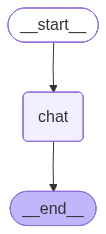

In [21]:
chat

In [22]:
# input1 = {'message': HumanMessage(content ="What is the capital of Maharashtra")}
# chat.invoke(input1)

In [24]:
thread_id = '1'

while True:

    inp = input("Enter the input: ")

    print("USER :" , inp)

    if inp.strip().lower() in ["bye","exit","quit"]:
        break

    config = {'configurable':{'thread_id':thread_id}}

    res = chat.invoke({'message':[HumanMessage(content=inp)]},config = config)

    print("AI : ",res['message'][-1].content)




USER : Hello my name is Sakshi
AI :  Hello again, Sakshi! How can I help you today?
USER : can you tell me what is my name ?
AI :  Your name is Sakshi! How can I assist you further?
USER : what is 5+10
AI :  5 + 10 equals 15. If you have any more questions or need help with something else, feel free to ask!
USER : add 10 to the result
AI :  Adding 10 to 15 gives you 25. If you have any more calculations or questions, feel free to ask!
USER : exit


In [25]:
chat.get_state(config = config)

StateSnapshot(values={'message': [HumanMessage(content='Hello my name is sakshi', additional_kwargs={}, response_metadata={}, id='9ca2e916-37d2-4f95-806b-0de550970525'), AIMessage(content='Hello, Sakshi! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 13, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_aa07c96156', 'id': 'chatcmpl-CjQiD2lUpuGCL6eGT3m87RMH9wNxS', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--e2febd4d-61bb-48ae-8584-f63d62ee6028-0', usage_metadata={'input_tokens': 13, 'output_tokens': 12, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reaso